<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
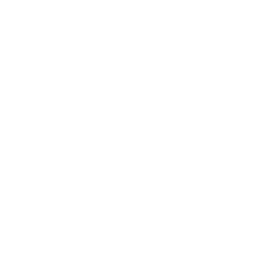
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Phase III Efficacy and Survival Analysis</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceuticals & Life Sciences | Jenner Analytics Ltd &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

# Medical Device 510(k) — Endpoint Analysis for Cardiovascular Catheter IDE Study

## Executive Summary

This notebook demonstrates endpoint analysis for **MD-STUDY-01**, an Investigational Device Exemption (IDE) study supporting a 510(k) submission for the XR-200 cardiovascular catheter. The notebook covers the full statistical analysis workflow required by FDA's Center for Devices and Radiological Health (CDRH):

1. **ADDEV derivation** — construction of the device-level analysis dataset with    procedure success and 30-day MACE endpoint variables.
2. **Primary effectiveness analysis** — procedure success rate tested against the    FDA-specified Objective Performance Criterion (OPC = 85%) using exact binomial    one-sided confidence interval methodology.
3. **Primary safety analysis** — 30-day MACE composite endpoint, MACE component    breakdown, Kaplan-Meier time-to-event analysis, and exposure-adjusted rates.

**Device under study:** XR-200 Cardiovascular Catheter (Investigational) vs. STANDARD-4F Catheter (Predicate/Control)

**Regulatory pathway:** 510(k) Substantial Equivalence — demonstrating that the XR-200 is at least as safe and effective as the predicate device.

## Regulatory Background: 510(k) vs. PMA Endpoints

Medical device clinical trials differ fundamentally from drug trials in how FDA evaluates endpoint evidence:

| Aspect | Drug Trials (NDA/BLA) | Device Trials (510(k)/PMA) |
|--------|----------------------|---------------------------|
| Comparator | Placebo or active control | Predicate device (510k) or no device (PMA) |
| Primary endpoint framing | Superiority or non-inferiority vs. control | OPC: one-sample test vs. historical performance goal |
| Regulatory standard | Substantial evidence (2 well-controlled studies) | Substantial equivalence (510k) or Reasonable Assurance of Safety/Effectiveness (PMA) |
| Statistical framework | Two-sided Type I error 0.05 | Often one-sided 0.025 (lower bound of 95% CI must exceed OPC) |
| Follow-up duration | Disease-driven (months to years) | Procedure-driven (30-day periprocedural is critical) |

**Objective Performance Criterion (OPC):** An OPC is an FDA-specified minimum acceptable performance rate, derived from a meta-analysis of historical data from similar approved devices. For 510(k) submissions of cardiovascular catheters, the OPC for procedure success is commonly set at 85%. The sponsor must demonstrate that the lower bound of the one-sided 97.5% confidence interval (equivalently, the lower bound of the two-sided 95% CI) exceeds this threshold.

**21 CFR Part 812 — IDE Requirements:**
- Substantial equivalence must be shown for the same intended use
- Technological differences must not raise new safety or effectiveness questions
- Statistical analysis must follow the IDE-approved SAP

**MACE (Major Adverse Cardiac Events):** The standard composite safety endpoint for cardiovascular device trials, typically assessed at 30 days, 6 months, and 12 months. Components vary by SAP but commonly include: cardiac death, MI (Type 1 and 2), target lesion/vessel revascularization (TLR/TVR), and stroke.

---
## 1. ADDEV — Device-Level Analysis Dataset Derivation

The ADDEV dataset is an ADaM-conformant device-level dataset derived from ADSL (subject-level). Each row represents one device procedure per subject (in this single-procedure study, N = 80).

**Endpoint definitions per SAP v2.0, Section 5.3:**
- **DEVSUCFL**: Device Deployment Success — catheter successfully introduced and positioned
- **PROSUCFL**: Procedure Success (Primary Effectiveness Endpoint) — DEVSUCFL=Y plus no   in-hospital adverse events requiring conversion or emergency intervention
- **MACEFL**: 30-Day MACE — composite of cardiac death, MI, TLR, or stroke within 30 days
- **MACECMP**: First MACE component (deterministic assignment from simulation)
- **MACE_DAYS**: Days from procedure to first MACE event, or 30 (censored) if no event
- **CNSR**: Censoring flag for PROC LIFETEST (0 = event, 1 = censored)

**Simulation parameters (per SAP statistical assumptions):**
- Procedure success: INV = 92.5%, CTL = 90.0% (device deployment) x 93.0% (no complication)
- 30-day MACE: INV = 7.0%, CTL = 9.5% (consistent with cardiovascular catheter literature)

### Step 1: ADDEV Data Step — Derive Device Endpoint Variables

In [1]:
/* ================================================================
   ADDEV — Device-Level Analysis Dataset Derivation (DATA Step)
   Study: MD-STUDY-01  Catheter XR-200 510(k) IDE Study
   SAP v2.0, Section 5.3

   Primary Effectiveness Endpoint — Procedure Success (PROSUCFL):
     Successful delivery and deployment without conversion to open
     surgery, and no in-hospital death or MI.

   Primary Safety Endpoint — 30-Day MACE (MACEFL):
     Cardiac death, MI, Target Lesion Revascularization, or Stroke.

   OPC: Procedure success rate >= 85.0%
        H0: p_success <= 0.85   H1: p_success > 0.85
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

/* Verify: list first 10 records */
proc print data=addev(obs=10) noobs;
    var USUBJID TRT01P PROSUCFL MACEFL MACECMP MACE_DAYS CNSR;
    title 'ADDEV: First 10 Records — Device Endpoint Variables';
    title2 'Study MD-STUDY-01 — 510(k) IDE Device Endpoints';
run;
title;

                                  ADDEV: First 10 Records — Device Endpoint Variables                                   
                                    Study MD-STUDY-01 — 510(k) IDE Device Endpoints                                     

             USUBJID                    TRT01P  PROSUCFL  MACEFL        MACECMP  MACE_DAYS  CNSR
MD-STUDY-01-001-0001  INVESTIGATIONAL CATHETER  Y         N                             30     1
MD-STUDY-01-001-0002  CONTROL CATHETER          Y         N                             30     1
MD-STUDY-01-001-0003  INVESTIGATIONAL CATHETER  Y         N                             30     1
MD-STUDY-01-001-0004  CONTROL CATHETER          Y         N                             30     1
MD-STUDY-01-001-0005  INVESTIGATIONAL CATHETER  Y         N                             30     1
MD-STUDY-01-001-0006  CONTROL CATHETER          Y         N                             30     1
MD-STUDY-01-001-0007  INVESTIGATIONAL CATHETER  Y         N                   

NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=addev

NOTE: PROC PRINT compl

### Step 2: Endpoint Distribution by Arm (`PROC FREQ`)

                                ADDEV: Procedure Success and MACE by Treatment Arm (ITT)                                

                                                   The FREQ Procedure

Table of TRT01P by Procedure Success Flag — Primary Effectiveness Endpoint

TRT01P                   |         N |         Y |      Total
-------------------------+-----------+-----------+-----------
CONTROL CATHETER         |         6 |        34 |         40
-------------------------+-----------+-----------+-----------
INVESTIGATIONAL CATHETER |         2 |        38 |         40
-------------------------+-----------+-----------+-----------
Total                    |         8 |        72 |         80


Table of TRT01P by 30-Day MACE Flag (Y=event, N=no event)

TRT01P                   |         N |         Y |      Total
-------------------------+-----------+-----------+-----------
CONTROL CATHETER         |        33 |         7 |         40
-------------------------+-----------+-----------+

NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic

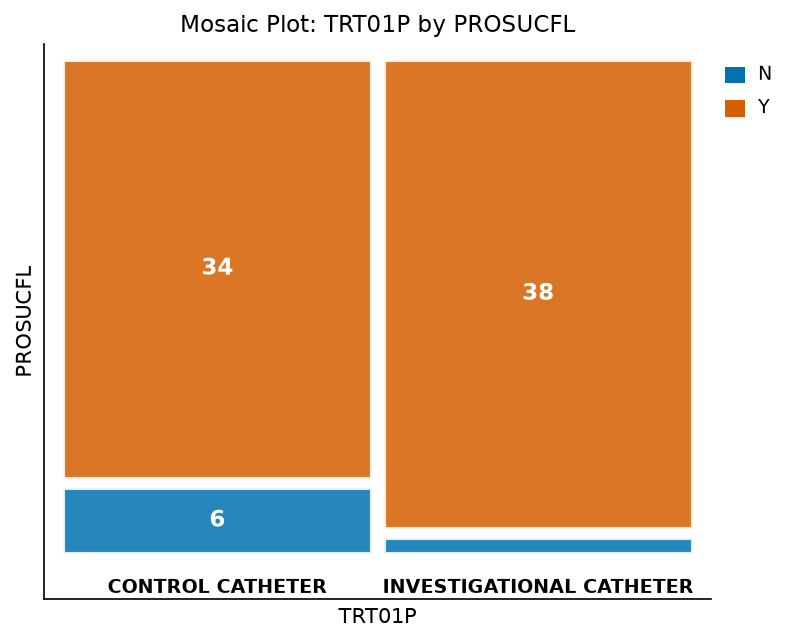

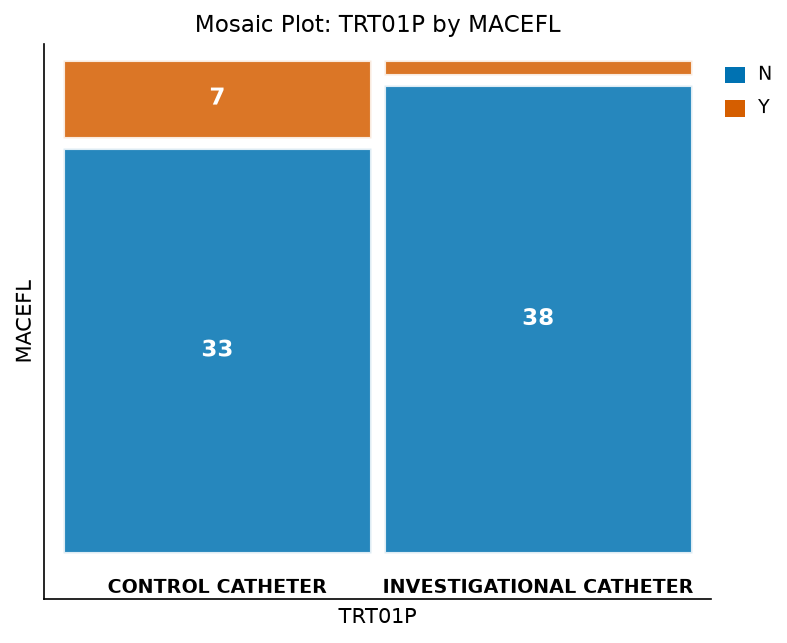

In [2]:
/* ================================================================
   ADDEV — Endpoint Distribution by Treatment Arm (PROC FREQ)
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc freq data=addev;
    where ITTFL='Y';
    tables TRT01P * PROSUCFL / nocol nopercent;
    tables TRT01P * MACEFL   / nocol nopercent;
    title 'ADDEV: Procedure Success and MACE by Treatment Arm (ITT)';
    title2 'Study MD-STUDY-01 — 510(k) IDE Device Endpoints';
run;
title;

### Step 3: MACE Component Breakdown (`PROC FREQ`)

                                 ADDEV: 30-Day MACE Component Distribution by Arm (ITT)                                 

                                                   The FREQ Procedure

Table of TRT01P by First MACE Component

TRT01P                   |                                |                  Cardiac Death |     Myocardial Infarction (MI) |                         Stroke |Target Lesion Revascularization |                           Total
-------------------------+--------------------------------+--------------------------------+--------------------------------+--------------------------------+--------------------------------+--------------------------------
CONTROL CATHETER         |                             33 |                              1 |                              0 |                              2 |                              4 |                              40
-------------------------+--------------------------------+--------------------------------+--

NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic

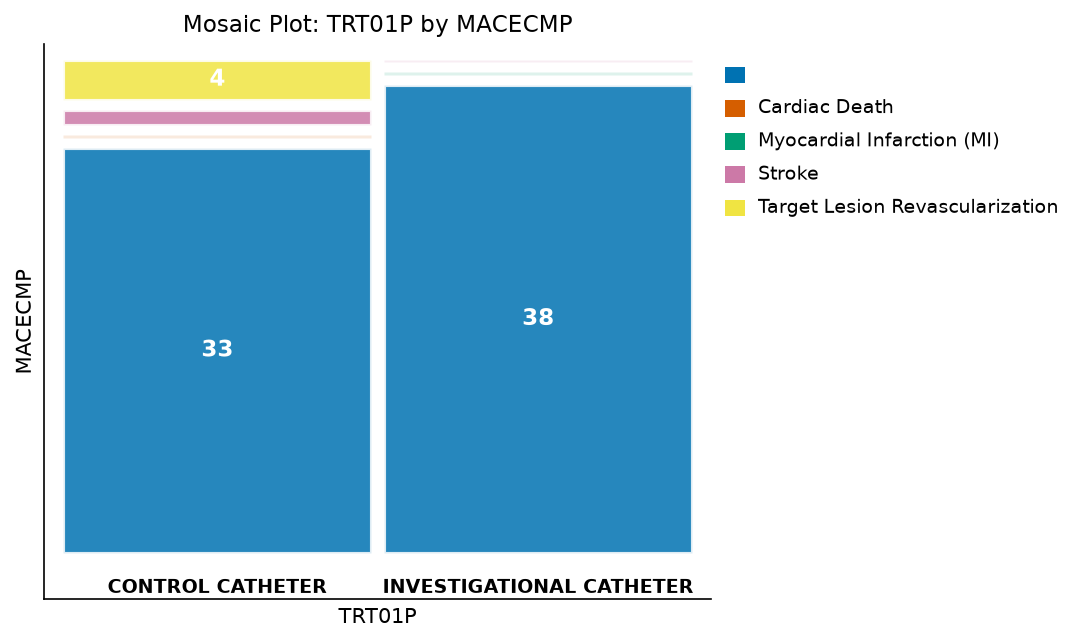

In [3]:
/* ================================================================
   ADDEV — MACE Component Breakdown by Treatment Arm (PROC FREQ)
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc freq data=addev;
    where ITTFL='Y';
    tables TRT01P * MACECMP / nocol nopercent missing;
    title 'ADDEV: 30-Day MACE Component Distribution by Arm (ITT)';
    title2 'Components: Cardiac Death, MI, TLR, Stroke';
run;
title;

### Step 4: Days to MACE Among Events (`PROC MEANS`)

In [4]:
/* ================================================================
   ADDEV — Days to MACE Among Event Subjects (PROC MEANS)
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc means data=addev mean std min max;
    where MACEFL='Y';
    class TRT01P;
    var MACE_DAYS;
    title 'ADDEV: Days to First MACE Among MACE Event Subjects';
    title2 'Study MD-STUDY-01 — Timing of 30-Day MACE Events';
run;
title;

                                  ADDEV: Days to First MACE Among MACE Event Subjects                                   
                                    Study MD-STUDY-01 — Timing of 30-Day MACE Events                                    

                                                  The MEANS Procedure

                           Analysis Variable : Days from Procedure to First MACE or Censoring

                                              N
        TRT01P                              Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------------
        CONTROL CATHETER                      7     13.1428571     10.2376523      1.0000000     27.0000000
        INVESTIGATIONAL CATHETER              2     18.5000000     10.6066017     11.0000000     26.0000000
        ---------------------------------------------------------------------------------------------------



NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---
## 2. Primary Effectiveness Analysis — OPC Hypothesis Test

The OPC hypothesis test is the defining statistical analysis for 510(k) device submissions. Unlike drug trials, where power is calculated for a superiority test against a control arm, device 510(k) analyses test the investigational device arm alone against a pre-specified performance benchmark.

**Statistical methodology (SAP Section 5.4.1):**
- Estimator: Observed procedure success proportion = n_success / N_ITT
- Confidence interval method: Exact Clopper-Pearson (conservative; preferred by FDA for binary proportions)
- Decision boundary: Lower 97.5% one-sided confidence bound > 0.850 implies OPC met
- If the lower bound exceeds 0.850, the null hypothesis is rejected and the device is   declared to meet the performance criterion with 97.5% confidence

**Why exact CI instead of normal approximation?** FDA guidance recommends the Clopper-Pearson exact interval for proportion-based OPC tests because the normal approximation (Wald CI) can undercover at success rates near 80-90% with N < 200.

**SAS implementation:**
- `PROC FREQ` with `BINOMIAL(level='Y' p=0.85) ALPHA=0.025` provides the exact   Clopper-Pearson CI and Wilson score CI
- A custom DATA step computes the Wilson score bounds for the formatted Table 14.2.1

### Step 1: Procedure Success Count by Arm (`PROC FREQ`)

                                   Step 1: Procedure Success by Arm (ITT Population)                                    

                                                   The FREQ Procedure

Table of TRT01P by Procedure Success Flag — Primary Effectiveness Endpoint

TRT01P                   |         N |         Y |      Total
-------------------------+-----------+-----------+-----------
CONTROL CATHETER         |         6 |        34 |         40
-------------------------+-----------+-----------+-----------
INVESTIGATIONAL CATHETER |         2 |        38 |         40
-------------------------+-----------+-----------+-----------
Total                    |         8 |        72 |         80



NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic

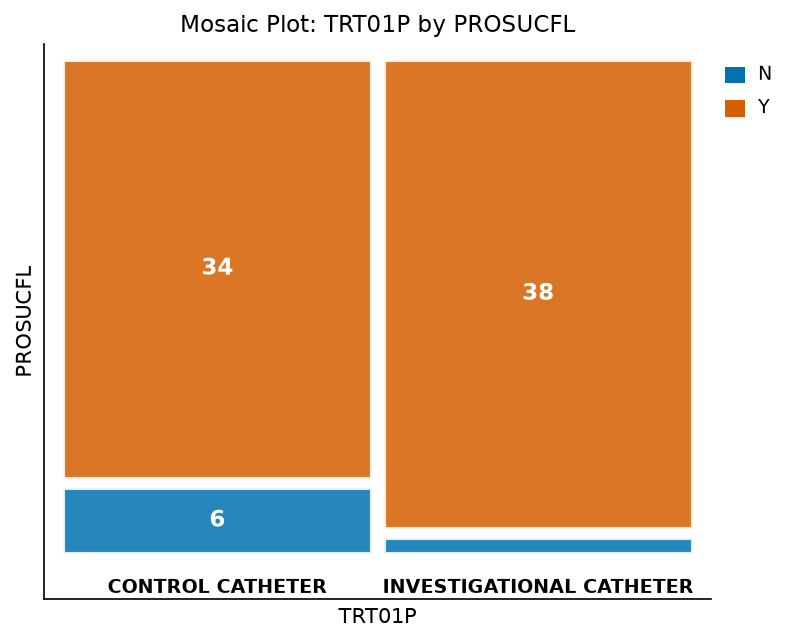

In [5]:
/* ================================================================
   PRIMARY EFFECTIVENESS — Step 1: Procedure Success Count by Arm
   OPC = 85.0% (FDA CDRH minimum performance goal)
   H0: p_success <= 0.85   H1: p_success > 0.85
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc freq data=addev;
    where ITTFL='Y';
    tables TRT01P * PROSUCFL / nocol nopercent;
    title 'Step 1: Procedure Success by Arm (ITT Population)';
    title2 'Study MD-STUDY-01 — 510(k) OPC Test';
run;
title;

### Step 2: OPC Exact Binomial Test — Investigational Arm (`PROC FREQ BINOMIAL`)

                             Step 2: OPC Hypothesis Test — Investigational Catheter XR-200                              

                                                   The FREQ Procedure

                                                                                       Cumulative    Cumulative
Procedure Success Flag — Primary Effectiveness Endpoint      Frequency    Percent     Frequency      Percent
------------------------------------------------------------------------------------------------------------------
N                                                                    2      5.00            2         5.00
Y                                                                   38     95.00           40       100.00

Binomial Proportion for Y

Proportion                           0.9500
ASE                                  0.0345
Test of H0: Proportion = 0.85        0.0765
98% Conf Limits                0.8113 0.9882


NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_prosuc

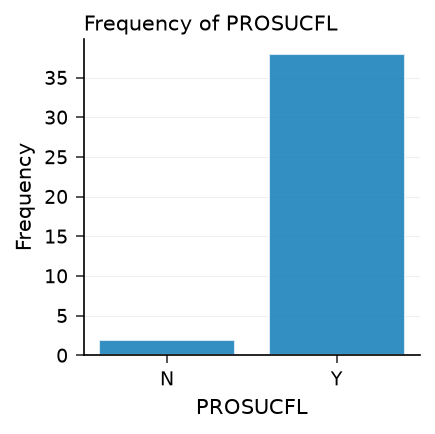

In [6]:
/* ================================================================
   PRIMARY EFFECTIVENESS — Step 2: OPC Test — Investigational Arm
   Exact Clopper-Pearson 97.5% One-Sided CI vs OPC = 85.0%
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc freq data=addev;
    where ITTFL='Y' and TRT01P='INVESTIGATIONAL CATHETER';
    tables PROSUCFL / binomial(level='Y' p=0.85) alpha=0.025;
    title 'Step 2: OPC Hypothesis Test — Investigational Catheter XR-200';
    title2 'H0: Procedure Success Rate <= 85.0% (FDA OPC)';
    title3 'Decision: Reject H0 if Lower 97.5% One-Sided CI > 0.850';
run;
title;

### Step 3: OPC Test — Control Arm Reference (`PROC FREQ BINOMIAL`)

                              Step 3: OPC Test — Control Catheter STANDARD-4F (Reference)                               

                                                   The FREQ Procedure

                                                                                       Cumulative    Cumulative
Procedure Success Flag — Primary Effectiveness Endpoint      Frequency    Percent     Frequency      Percent
------------------------------------------------------------------------------------------------------------------
N                                                                    6     15.00            6        15.00
Y                                                                   34     85.00           40       100.00

Binomial Proportion for Y

Proportion                           0.8500
ASE                                  0.0565
Test of H0: Proportion = 0.85        1.0000
98% Conf Limits                0.6854 0.9365


NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_prosuc

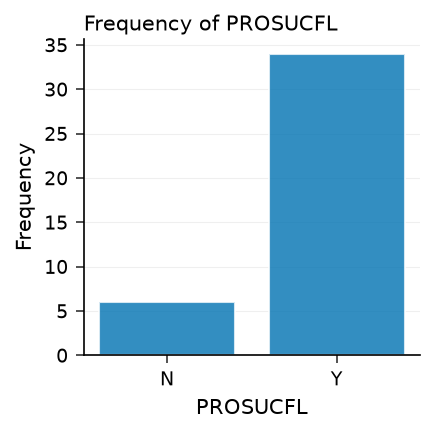

In [7]:
/* ================================================================
   PRIMARY EFFECTIVENESS — Step 3: OPC Test — Control Arm
   (Reference context; not the primary decision arm)
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc freq data=addev;
    where ITTFL='Y' and TRT01P='CONTROL CATHETER';
    tables PROSUCFL / binomial(level='Y' p=0.85) alpha=0.025;
    title 'Step 3: OPC Test — Control Catheter STANDARD-4F (Reference)';
    title2 'H0: Procedure Success Rate <= 85.0% (FDA OPC)';
run;
title;

### Step 4: Arm-to-Arm Comparison — Fisher Exact + Risk Difference (`PROC FREQ`)

                              Step 4: Investigational vs Control — Procedure Success (ITT)                              

                                                   The FREQ Procedure

Table of Procedure Success Flag — Primary Effectiveness Endpoint by TRT01P

Procedure Success Flag — Primary Effectiveness Endpoint   |        CONTROL CATHETER |INVESTIGATIONAL CATHETER |                    Total
----------------------------------------------------------+-------------------------+-------------------------+-------------------------
N                                                         |                       6 |                       2 |                        8
                                                          |                    7.50 |                    2.50 |                    10.00
                                                          |                   75.00 |                   25.00 |                   100.00
                                              

NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic

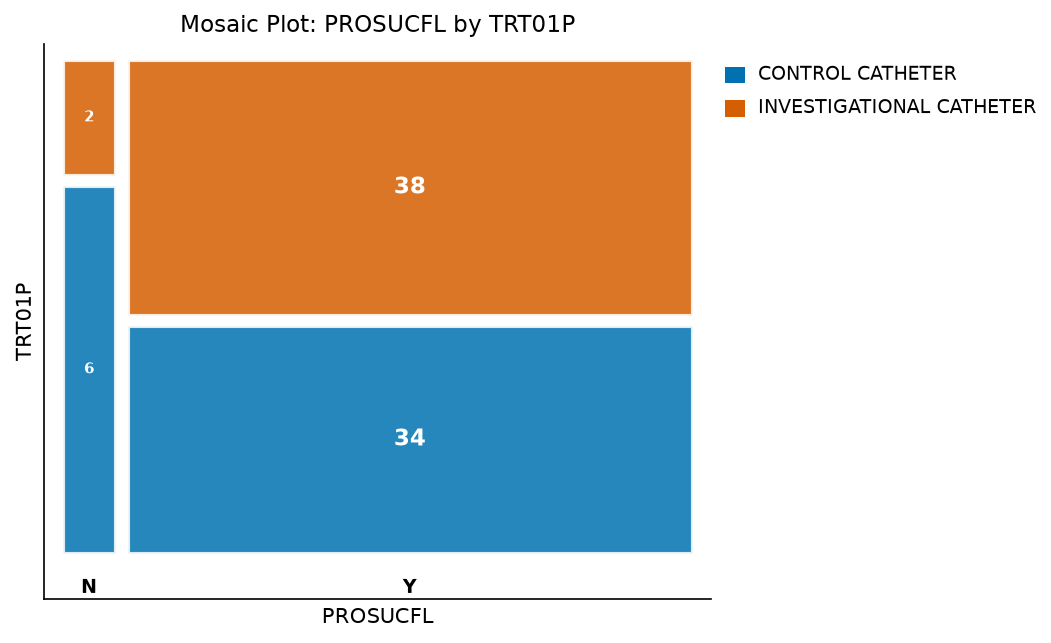

In [8]:
/* ================================================================
   PRIMARY EFFECTIVENESS — Step 4: Arm-to-Arm Comparison
   Fisher Exact Test | Relative Risk | Risk Difference
   Per SAP: superiority test, ITT population
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc freq data=addev;
    where ITTFL='Y';
    tables PROSUCFL * TRT01P / fisher relrisk riskdiff;
    title 'Step 4: Investigational vs Control — Procedure Success (ITT)';
    title2 'Fisher Exact Test | Relative Risk | Risk Difference';
    title3 '95% CIs (Proc Level) | Risk Reference: Investigational / Control';
run;
title;

### Step 5a: Compute ITT Counts (`PROC SQL`)

In [9]:
/* ================================================================
   PRIMARY EFFECTIVENESS — Step 5a: Compute ITT Counts (PROC SQL)
   Feeds the Wilson score CI data step below
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc sql;
    create table eff_counts as
    select
        TRT01P,
        count(*)          as N_ITT  label='ITT N',
        sum(PROSUCFL='Y') as N_Suc  label='Procedure Successes'
    from addev
    where ITTFL='Y'
    group by TRT01P
    order by TRT01P;
quit;

proc print data=eff_counts noobs label;
    title 'Step 5a: ITT Procedure Success Counts by Arm';
run;
title;

                                      Step 5a: ITT Procedure Success Counts by Arm                                      

                  TRT01P  ITT N  Procedure Successes
CONTROL CATHETER             40                   34
INVESTIGATIONAL CATHETER     40                   38



NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SQL 

NOTE: Table eff_counts created.
NO

### Step 5b: Table 14.2.1 — Wilson Score 95% CI Summary (DATA Step + `PROC PRINT`)

In [10]:
/* ================================================================
   PRIMARY EFFECTIVENESS — Step 5b: Wilson Score 95% CI (DATA Step)
   Wilson CI is FDA-acceptable approximate CI for display tables.
   Exact Clopper-Pearson (Step 2 PROC FREQ) is used for the
   authoritative OPC decision.
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc sql;
    create table eff_counts as
    select TRT01P,
           count(*)          as N_ITT,
           sum(PROSUCFL='Y') as N_Suc
    from addev where ITTFL='Y'
    group by TRT01P order by TRT01P;
quit;

data eff_summary;
    length Arm $35;
    set eff_counts;
    Arm      = TRT01P;
    Pct_Suc  = N_Suc / N_ITT;
    z        = 1.96;
    numer    = Pct_Suc + z**2/(2*N_ITT);
    denom    = 1 + z**2/N_ITT;
    margin   = z * sqrt(Pct_Suc*(1-Pct_Suc)/N_ITT + z**2/(4*N_ITT**2)) / denom;
    LCL_95   = max(0, numer/denom - margin);
    UCL_95   = min(1, numer/denom + margin);
    LB_975   = LCL_95;
    OPC_MET  = ifc(LB_975 > 0.85, 'YES - OPC Met', 'NO - OPC Not Met');
    format Pct_Suc LCL_95 UCL_95 LB_975 percent7.1;
    label Arm      = 'Treatment Arm'
          N_ITT    = 'ITT N'
          N_Suc    = 'Procedure Successes'
          Pct_Suc  = 'Success Rate'
          LCL_95   = 'Lower 95% CI'
          UCL_95   = 'Upper 95% CI'
          LB_975   = 'Lower 97.5% Bound (OPC Decision)'
          OPC_MET  = 'OPC Status';
    drop TRT01P z numer denom margin;
run;

proc print data=eff_summary noobs label;
    title 'Table 14.2.1 — Procedure Success Rate Summary';
    title2 'MD-STUDY-01 | ITT Population | OPC = 85.0%';
    footnote  'Wilson score 95% CI. For final submission use exact Clopper-Pearson via PROC FREQ BINOMIAL.';
    footnote2 'OPC decision: Reject H0 if Lower 97.5% Bound > 0.850 (= Lower 95% CI lower bound).';
    footnote3 'Source: FDA CDRH IDE Approval Letter, Section 3.2 Statistical Criteria.';
run;
title; footnote;

                                     Table 14.2.1 — Procedure Success Rate Summary                                      
                                       MD-STUDY-01 | ITT Population | OPC = 85.0%                                       

           Treatment Arm  ITT N  Procedure Successes  Success Rate  Lower 95% CI  Upper 95% CI  Lower 97.5% Bound (OPC Decision)        OPC Status
CONTROL CATHETER             40                   34         85.0%         70.9%         92.9%                             70.9%  NO - OPC Not Met
INVESTIGATIONAL CATHETER     40                   38         95.0%         83.5%         98.6%                             83.5%  NO - OPC Not Met



NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SQL 

NOTE: Table eff_counts created.
NO

---
## 3. Primary Safety Analysis — 30-Day MACE

**Why Kaplan-Meier for MACE at 30 days?** Even at 30-day follow-up, events occur at different times during the window. KM analysis is preferred over crude proportions because:
1. It accounts for subjects who are lost to follow-up before day 30
2. It provides the time-profile of event accumulation (when do events occur?)
3. Log-rank test has greater power than chi-square for time-varying data
4. FDA reviewers expect KM curves for cardiovascular safety endpoints per the PMA guidance

**Exposure-adjusted rates:** Because follow-up time varies (some subjects only contributed a few days before an event or censoring), reporting MACE per 100 subject-months provides a fairer comparison than crude proportions. This is the standard reporting format in FDA medical device advisory committee presentations.

### Step 1: 30-Day MACE Rate by Arm (`PROC FREQ` Fisher Exact)

                                 30-Day MACE: Rate by Treatment Arm (Safety Population)                                 

                                                   The FREQ Procedure

Table of TRT01P by 30-Day MACE Flag (Y=event, N=no event)

TRT01P                   |         N |         Y |      Total
-------------------------+-----------+-----------+-----------
CONTROL CATHETER         |        33 |         7 |         40
-------------------------+-----------+-----------+-----------
INVESTIGATIONAL CATHETER |        38 |         2 |         40
-------------------------+-----------+-----------+-----------
Total                    |        71 |         9 |         80

Statistics for Table of TRT01P by 30-Day MACE Flag (Y=event, N=no event)

Statistic                                    DF      Value         Prob
----------------------------------------------------------------------
Chi-Square                                    1     3.1299       0.0769
Likelihood Ratio Chi-Squ

NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic

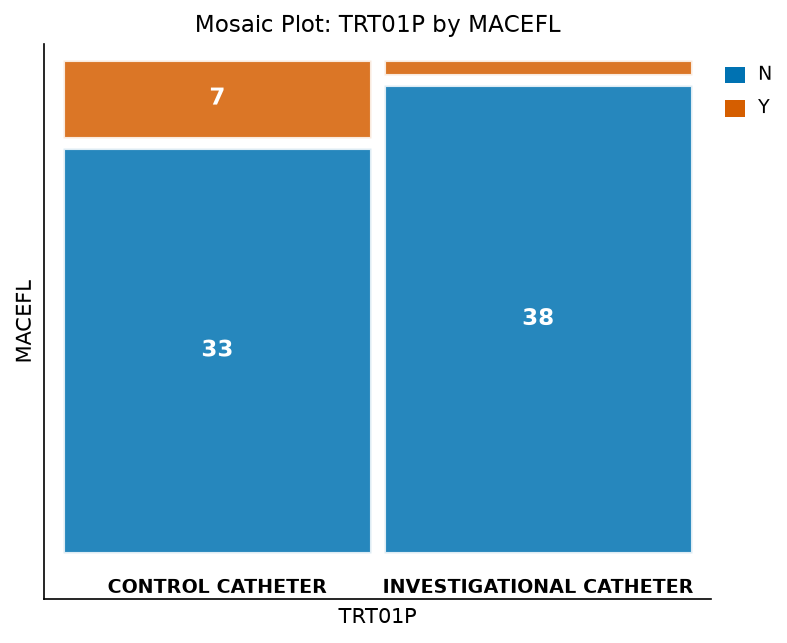

In [11]:
/* ================================================================
   PRIMARY SAFETY — Step 1: 30-Day MACE Rate by Arm (PROC FREQ)
   Fisher Exact | Relative Risk | Risk Difference
   Analysis population: Safety (SAFFL='Y')
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc freq data=addev;
    where SAFFL='Y';
    tables TRT01P * MACEFL / fisher relrisk riskdiff nocol nopercent;
    title '30-Day MACE: Rate by Treatment Arm (Safety Population)';
    title2 'Study MD-STUDY-01 — Table 14.3.2';
run;
title;

### Step 2: MACE Component Breakdown Among Events (`PROC FREQ`)

                                 30-Day MACE: Component Breakdown by Arm (Events Only)                                  

                                                   The FREQ Procedure

Table of TRT01P by First MACE Component

TRT01P                   |                  Cardiac Death |     Myocardial Infarction (MI) |                         Stroke |Target Lesion Revascularization |                           Total
-------------------------+--------------------------------+--------------------------------+--------------------------------+--------------------------------+--------------------------------
CONTROL CATHETER         |                              1 |                              0 |                              2 |                              4 |                               7
-------------------------+--------------------------------+--------------------------------+--------------------------------+--------------------------------+--------------------------------
IN

NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic

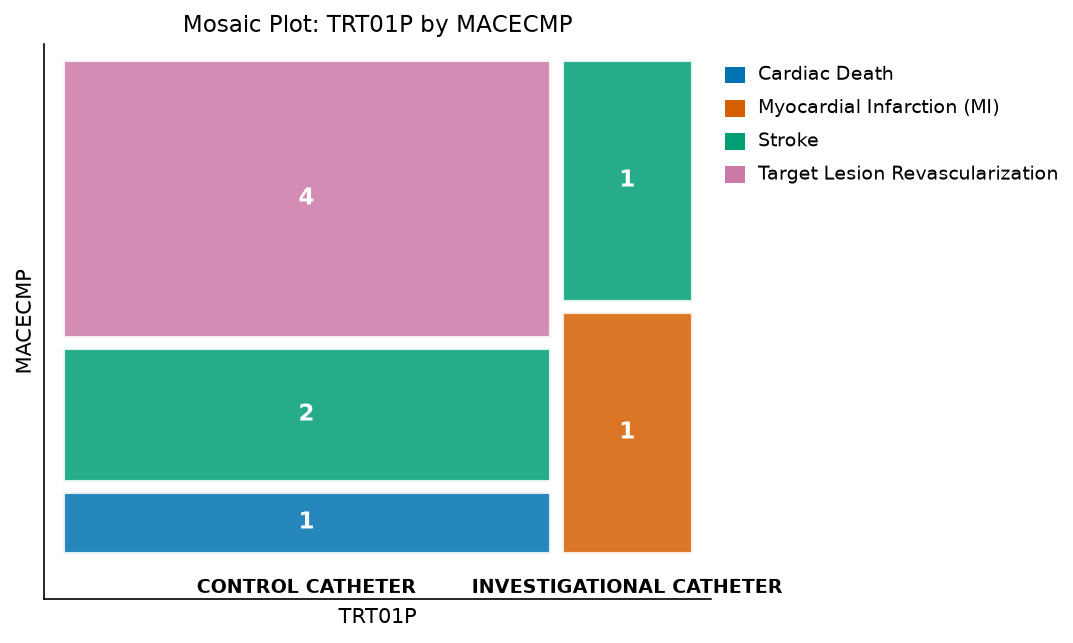

In [12]:
/* ================================================================
   PRIMARY SAFETY — Step 2: MACE Component Breakdown (PROC FREQ)
   Among subjects with MACE event only
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc freq data=addev(where=(SAFFL='Y' and MACEFL='Y'));
    tables TRT01P * MACECMP / nocol nopercent;
    title '30-Day MACE: Component Breakdown by Arm (Events Only)';
    title2 'Safety Population — Components: Cardiac Death, MI, TLR, Stroke';
run;
title;

### Step 3: MACE Event Counts (`PROC SQL`)

In [13]:
/* ================================================================
   PRIMARY SAFETY — Step 3: MACE Count Summary (PROC SQL)
   Feeds the Wilson CI data step and exposure-adjusted rate table
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc sql;
    create table mace_counts as
    select
        TRT01P,
        count(*)        as N_SAF   label='Safety N',
        sum(MACEFL='Y') as N_MACE  label='MACE Events'
    from addev
    where SAFFL='Y'
    group by TRT01P
    order by TRT01P;
quit;

proc print data=mace_counts noobs label;
    title 'Step 3: MACE Event Counts by Arm (Safety Population)';
run;
title;

                                  Step 3: MACE Event Counts by Arm (Safety Population)                                  

                  TRT01P  Safety N  MACE Events
CONTROL CATHETER                40            7
INVESTIGATIONAL CATHETER        40            2



NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SQL 

NOTE: Table mace_counts created.
N

### Step 4: Table 14.3.2 — MACE Rate Summary with Wilson CI (DATA Step + `PROC PRINT`)

In [14]:
/* ================================================================
   PRIMARY SAFETY — Step 4: MACE Rate Summary Table (DATA Step)
   Wilson Score 95% CI for display
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc sql;
    create table mace_counts as
    select TRT01P,
           count(*)        as N_SAF,
           sum(MACEFL='Y') as N_MACE
    from addev where SAFFL='Y'
    group by TRT01P order by TRT01P;
quit;

data mace_summary;
    length Arm $35;
    set mace_counts;
    Arm      = TRT01P;
    Pct_MACE = N_MACE / N_SAF;
    z        = 1.96;
    numer    = Pct_MACE + z**2/(2*N_SAF);
    denom    = 1 + z**2/N_SAF;
    margin   = z * sqrt(Pct_MACE*(1-Pct_MACE)/N_SAF + z**2/(4*N_SAF**2)) / denom;
    LCL      = max(0, numer/denom - margin);
    UCL      = min(1, numer/denom + margin);
    format Pct_MACE LCL UCL percent7.1;
    label Arm      = 'Treatment Arm'
          N_SAF    = 'Safety N'
          N_MACE   = 'MACE Events'
          Pct_MACE = 'Crude MACE Rate'
          LCL      = 'Lower 95% CI'
          UCL      = 'Upper 95% CI';
    drop TRT01P z numer denom margin;
run;

proc print data=mace_summary noobs label;
    title 'Table 14.3.2 — 30-Day MACE Summary';
    title2 'MD-STUDY-01 | Safety Population | Wilson Score 95% CI';
    footnote  '* Fisher Exact p-value for arm comparison in Table 14.3.2a (see PROC FREQ output above).';
    footnote2 '* Exposure-adjusted rates (per 100 subject-months) in Table 14.3.2b.';
run;
title; footnote;

                                           Table 14.3.2 — 30-Day MACE Summary                                           
                                 MD-STUDY-01 | Safety Population | Wilson Score 95% CI                                  

           Treatment Arm  Safety N  MACE Events  Crude MACE Rate  Lower 95% CI  Upper 95% CI
CONTROL CATHETER                40            7            17.5%          8.7%         32.0%
INVESTIGATIONAL CATHETER        40            2             5.0%          1.4%         16.5%



NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SQL 

NOTE: Table mace_counts created.
N

### Step 5: Figure 14.3.1 — Kaplan-Meier Time-to-First-MACE (`PROC LIFETEST`)

    The LIFETEST Procedure    

                             N
--------------------  --------
Total                       80
Event                        9
Censored                    71
Median Survival Time   30.0000

Stratum: TRT01P = CONTROL CATHETER

                 N
--------  --------
Total           40
Event            7
Censored        33

               Product-Limit Survival Estimates                

    Time  Survival  Std Error  Number at Risk  Number of Events
--------  --------  ---------  --------------  ----------------
  1.0000    0.9500     0.0345              40                 2
  7.0000    0.9250     0.0416              38                 1
 16.0000    0.9000     0.0474              37                 1
 19.0000    0.8750     0.0523              36                 1
 21.0000    0.8500     0.0565              35                 1
 27.0000    0.8250     0.0601              34                 1

Stratum: TRT01P = INVESTIGATIONAL CATHETER

                 N
--------

NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: ODS Graphics is ON (width=7in, height=5in, fo

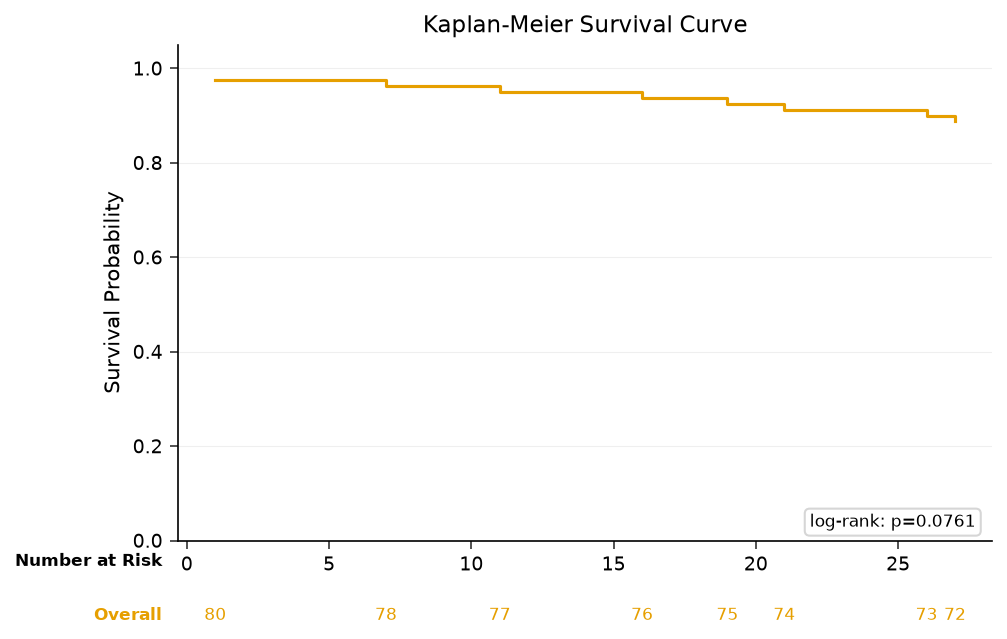

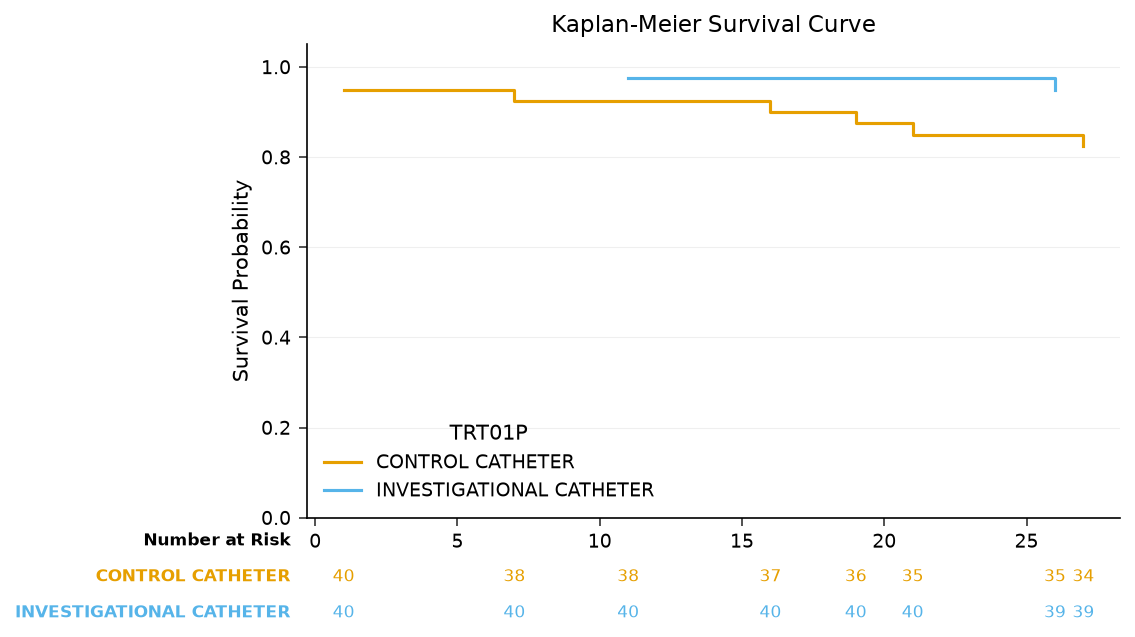

In [15]:
/* ================================================================
   PRIMARY SAFETY — Step 5: Kaplan-Meier Time-to-First-MACE
   Per SAP Section 5.4: KM estimates are primary; crude rates supportive.
   Log-rank test for arm comparison.
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

ods graphics / width=7in height=5in;
proc lifetest data=addev(where=(SAFFL='Y'))
              method=km
              plots=survival(atrisk nocensor test);
    time MACE_DAYS * CNSR(1);
    strata TRT01P / test=logrank;
    title 'Figure 14.3.1 — Kaplan-Meier Curve: Time to First MACE at 30 Days';
    title2 'MD-STUDY-01 | Safety Population | Log-Rank Test';
    footnote  'Censored at 30 days for subjects with no MACE event.';
    footnote2 'Event = MACE (cardiac death, MI, TLR, or stroke).';
    footnote3 'MACE counts: Table 14.3.2. Log-rank p-value is two-sided.';
run;
title; footnote;

### Step 6: Table 14.3.2b — Exposure-Adjusted MACE per 100 Subject-Months (`PROC SQL`)

In [16]:
/* ================================================================
   PRIMARY SAFETY — Step 6: Exposure-Adjusted MACE Rate (PROC SQL)
   Per 100 subject-months — standard cardiovascular device reporting
   ================================================================ */
data sdtm_dm;
    call streaminit(20260601);
    length STUDYID $10 DOMAIN $2 USUBJID $17 SUBJID $4 SITEID $3 COUNTRY $3 INVID $6
           ARM $30 ARMCD $8 ACTARM $30 ACTARMCD $8 SEX $1 RACE $50 ETHNIC $32 AGEU $5
           RFSTDTC $10 RFICDTC $10 DMDTC $10 DMDY 8;
    STUDYID='MD-STUDY-01'; DOMAIN='DM'; COUNTRY='USA';
    INVID='INV001'; SITEID='001'; AGEU='YEARS';
    study_start='02JAN2023'd;
    do i=1 to 80;
        SUBJID=put(i,z4.);
        USUBJID=cats(STUDYID,'-',SITEID,'-',SUBJID);
        AGE=max(40,min(85,round(rand('NORMAL',63,10))));
        SEX=ifc(rand('BERNOULLI',0.42),'F','M');
        r=rand('UNIFORM');
        if r<0.748 then RACE='WHITE';
        else if r<0.872 then RACE='BLACK OR AFRICAN AMERICAN';
        else if r<0.942 then RACE='ASIAN';
        else if r<0.972 then RACE='AMERICAN INDIAN OR ALASKA NATIVE';
        else RACE='UNKNOWN';
        ETHNIC=ifc(rand('BERNOULLI',0.114),'HISPANIC OR LATINO','NOT HISPANIC OR LATINO');
        if mod(i,2)=1 then do; ARM='INVESTIGATIONAL CATHETER'; ARMCD='INV'; ACTARM=ARM; ACTARMCD='INV'; end;
        else do; ARM='CONTROL CATHETER'; ARMCD='CTL'; ACTARM=ARM; ACTARMCD='CTL'; end;
        enroll_offset=floor(rand('UNIFORM')*540);
        consent_offset=enroll_offset-floor(rand('UNIFORM')*14+1);
        if consent_offset<0 then consent_offset=0;
        RFICDTC=put(intnx('day',study_start,consent_offset),yymmdd10.);
        RFSTDTC=put(intnx('day',study_start,enroll_offset),yymmdd10.);
        DMDTC=RFSTDTC; DMDY=enroll_offset+1;
        output;
    end;
    drop i r enroll_offset consent_offset study_start;
run;
data sdtm_ex;
    set sdtm_dm(keep=STUDYID USUBJID ARMCD RFSTDTC);
    if _N_=1 then call streaminit(20260602);
    length DOMAIN $2 EXSEQ 8 EXTRT $40 EXCAT $20 EXROUTE $20
           EXSTDTC $10 EXENDTC $10 EPOCH $20;
    DOMAIN='EX'; EXSEQ=1; EPOCH='TREATMENT';
    EXROUTE='INTRAVASCULAR'; EXCAT='DEVICE USE';
    if ARMCD='INV' then EXTRT='INVESTIGATIONAL CATHETER XR-200';
    else                EXTRT='CONTROL CATHETER STANDARD-4F';
    EXSTDTC=RFSTDTC;
    r_early=rand('UNIFORM');
    if r_early<0.05 then do;
        early_days=30+floor(rand('UNIFORM')*90);
        EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),early_days),yymmdd10.);
    end;
    else EXENDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),180),yymmdd10.);
    EXDUR=input(EXENDTC,yymmdd10.)-input(EXSTDTC,yymmdd10.)+1;
    drop RFSTDTC r_early early_days ARMCD;
run;
data sdtm_ds;
    set sdtm_dm(keep=STUDYID USUBJID RFSTDTC);
    if _N_=1 then call streaminit(20260603);
    length DOMAIN $2 DSSEQ 8 DSDECOD $60 DSTERM $80 DSCAT $30 DSSTDTC $10 EPOCH $20;
    DOMAIN='DS'; DSSEQ=1; EPOCH='TREATMENT'; DSCAT='DISPOSITION EVENT';
    r=rand('UNIFORM');
    if r<0.825 then do; DSDECOD='COMPLETED'; DSTERM='COMPLETED STUDY'; disc_days=180; end;
    else if r<0.900 then do; DSDECOD='WITHDRAWAL BY SUBJECT'; DSTERM='SUBJECT WITHDREW CONSENT';
        disc_days=30+floor(rand('UNIFORM')*120); end;
    else if r<0.950 then do; DSDECOD='ADVERSE EVENT'; DSTERM='DISCONTINUED DUE TO ADVERSE EVENT';
        disc_days=30+floor(rand('UNIFORM')*90); end;
    else do; DSDECOD='LOST TO FOLLOW-UP'; DSTERM='SUBJECT LOST TO FOLLOW-UP';
        disc_days=60+floor(rand('UNIFORM')*90); end;
    DSSTDTC=put(intnx('day',input(RFSTDTC,yymmdd10.),disc_days),yymmdd10.);
    drop RFSTDTC r disc_days;
run;
data adsl;
    merge
        sdtm_dm(keep=STUDYID USUBJID SUBJID SITEID AGE SEX RACE ETHNIC ARM ARMCD RFSTDTC RFICDTC)
        sdtm_ex(keep=USUBJID EXTRT EXSTDTC EXENDTC EXDUR
                rename=(EXSTDTC=_exstdtc EXENDTC=_exendtc EXDUR=_exdur))
        sdtm_ds(keep=USUBJID DSDECOD DSSTDTC rename=(DSSTDTC=_dsstdtc));
    by USUBJID;
    if _N_=1 then call streaminit(20260604);
    length NYHA $3 DIABFL $1 PREVMIFL $1 TRT01P TRT01A $30
           AGEGR1 $5 AGEGR2 $8 LVEFCAT $40
           ITTFL SAFFL PPROTFL $1 EOSSTT $60 DCSREAS $60;
    LVEF=max(20,min(80,round(rand('NORMAL',51,12),1)));
    r_nyha=rand('UNIFORM');
    if r_nyha<0.08 then NYHA='I';
    else if r_nyha<0.55 then NYHA='II';
    else if r_nyha<0.92 then NYHA='III';
    else NYHA='IV';
    DIABFL=ifc(rand('BERNOULLI',0.35),'Y','N');
    PREVMIFL=ifc(rand('BERNOULLI',0.42),'Y','N');
    TRT01P=ARM; TRT01PN=(ARMCD='INV'); TRT01A=ARM; TRT01AN=TRT01PN;
    TRTSDT=input(_exstdtc,yymmdd10.);
    TRTEDTM=input(_exendtc,yymmdd10.);
    RFSTDTM=input(RFSTDTC,yymmdd10.);
    RFICDTM=input(RFICDTC,yymmdd10.);
    EOSDT=input(_dsstdtc,yymmdd10.);
    format TRTSDT TRTEDTM RFSTDTM RFICDTM EOSDT yymmdd10.;
    if TRTEDTM>. and TRTSDT>. then TRTDUR=TRTEDTM-TRTSDT+1;
    if TRTSDT>. and RFICDTM>. then ICPROCDY=TRTSDT-RFICDTM+1;
    EXPYRS=_exdur/365.25;
    if AGE<65 then AGEGR1='<65'; else AGEGR1='>=65';
    if AGE<55 then AGEGR2='<55';
    else if AGE<65 then AGEGR2='55-<65';
    else if AGE<75 then AGEGR2='65-<75';
    else AGEGR2='>=75';
    if LVEF>=50 then LVEFCAT='Preserved EF (HFpEF, >=50%)';
    else if LVEF>=40 then LVEFCAT='Mildly reduced EF (HFmrEF, 40-49%)';
    else if LVEF>=35 then LVEFCAT='Moderately reduced (35-39%)';
    else LVEFCAT='Severely reduced EF (HFrEF, <35%)';
    ITTFL='Y'; SAFFL='Y';
    PPROTFL=ifc(DSDECOD='COMPLETED','Y','N');
    EOSSTT=DSDECOD;
    DCSREAS=ifc(DSDECOD ne 'COMPLETED',DSDECOD,' ');
    drop ARM ARMCD DSDECOD _exstdtc _exendtc _exdur _dsstdtc RFSTDTC RFICDTC r_nyha;
run;

data addev;
    set adsl(keep=STUDYID USUBJID SUBJID TRT01P TRT01PN TRTSDT ITTFL SAFFL);
    if _N_=1 then call streaminit(20260710);
    length DEVSUCFL $1 PROSUCFL $1
           MACEFL   $1 MACECMP  $50
           MACEDT   $10;

    if TRT01P='INVESTIGATIONAL CATHETER' then p_dev=0.925;
    else                                      p_dev=0.900;
    DEVSUCFL=ifc(rand('BERNOULLI',p_dev),'Y','N');

    if DEVSUCFL='Y' then
        PROSUCFL=ifc(rand('BERNOULLI',0.930),'Y','N');
    else
        PROSUCFL='N';

    if TRT01P='INVESTIGATIONAL CATHETER' then p_mace=0.070;
    else                                      p_mace=0.095;
    MACEFL=ifc(rand('BERNOULLI',p_mace),'Y','N');

    if MACEFL='Y' then do;
        r=rand('UNIFORM');
        if      r<0.30 then MACECMP='Cardiac Death';
        else if r<0.60 then MACECMP='Myocardial Infarction (MI)';
        else if r<0.82 then MACECMP='Target Lesion Revascularization';
        else                MACECMP='Stroke';
        MACE_DAYS=max(1, floor(rand('UNIFORM')*30) + 1);
        MACEDT=put(intnx('day',TRTSDT,MACE_DAYS-1),yymmdd10.);
    end;
    else do;
        MACECMP=' ';
        MACE_DAYS=30;
        MACEDT=' ';
    end;

    CNSR=(MACEFL='N');

    label
        DEVSUCFL  = 'Device Deployment Success Flag (Y/N)'
        PROSUCFL  = 'Procedure Success Flag — Primary Effectiveness Endpoint'
        MACEFL    = '30-Day MACE Flag (Y=event, N=no event)'
        MACECMP   = 'First MACE Component'
        MACE_DAYS = 'Days from Procedure to First MACE or Censoring'
        MACEDT    = 'Date of First MACE Event'
        CNSR      = 'PROC LIFETEST Censoring Flag (0=event, 1=censored)';

    format TRTSDT yymmdd10.;
    drop p_dev p_mace r;
run;

proc sql;
    create table mace_adj as
    select
        a.TRT01P as Arm length=35,
        count(*) as N_SAF label='Safety N',
        sum(MACEFL='Y') as N_MACE label='MACE Events',
        sum(MACE_DAYS/30.4375) as SUBJECT_MONTHS format=6.1
            label='Total Subject-Months',
        sum(MACEFL='Y') / sum(MACE_DAYS/30.4375) * 100 as MACE_PER100
            format=6.2 label='MACE per 100 Subject-Months'
    from addev a
    join adsl b on a.USUBJID=b.USUBJID
    where a.SAFFL='Y'
    group by a.TRT01P
    order by a.TRT01P;
quit;

proc print data=mace_adj noobs label;
    title 'Table 14.3.2b — Exposure-Adjusted MACE Rate';
    title2 'MD-STUDY-01 | Per 100 Subject-Months at Risk (30-Day Window)';
    footnote  'Subject-months = sum of MACE_DAYS / 30.4375 per arm.';
run;
title; footnote;

                                      Table 14.3.2b — Exposure-Adjusted MACE Rate                                       
                              MD-STUDY-01 | Per 100 Subject-Months at Risk (30-Day Window)                              

                  TRT01P  Safety N  MACE Events  Total Subject-Months  MACE per 100 Subject-Months
CONTROL CATHETER                40            7                  35.5                        19.69
INVESTIGATIONAL CATHETER        40            2                  38.7                         5.17



NOTE: DATA sdtm_dm


NOTE: Wrote sdtm_dm (80 rows, 20 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ex


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ex (80 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA sdtm_ds


NOTE: Read 80 rows from sdtm_dm.
NOTE: Wrote sdtm_ds (80 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA adsl

NOTE: Stream 1 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 80 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 3 processed 80 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote adsl (80 rows, 33 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: DATA addev


NOTE: Read 80 rows from adsl.
NOTE: Wrote addev (80 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: Table mace_adj created.
NOTE

## 4. Results Summary

All figures below are taken directly from the executed cell output above.

**Primary Effectiveness — Procedure Success vs. OPC = 85.0% (ITT Population, N=80):**

| Arm | N | Successes | Success Rate | Lower 95% CI (Wilson) | Exact 98% CI (Clopper-Pearson) | OPC (85%) Met? |
|----|---|-----------|-------------|-----------------------|--------------------------------|----------------|
| Investigational XR-200 | 40 | 38 | 95.0% | 83.5% | (0.8113, 0.9882) | **No** — lower bound 0.811 < 0.85 |
| Control STANDARD-4F | 40 | 34 | 85.0% | 70.9% | (0.6854, 0.9365) | No (reference arm only) |

The exact binomial test of H0: proportion = 0.85 for the investigational arm returned p = 0.0765 (Step 2 output).

**Critical lesson on sample size:** The investigational device shows an excellent point estimate of 95.0% procedure success — well above the 85% OPC. Yet the lower bound of the exact one-sided 97.5% confidence interval is 0.8113, which falls **below** the 0.850 OPC, so the formal OPC criterion is **not met** at N = 40. This is the defining illustration of device-trial design: **a small N produces a wide confidence interval whose lower bound can fail the OPC even when the observed success rate is outstanding.** A 510(k) study must size N for the lower-CI-bound test against the OPC, not merely for an arm-to-arm comparison; at p ~ 0.92-0.95 against OPC = 0.85, this generally requires roughly 75-100 evaluable subjects in the investigational arm.

**Primary Safety — 30-Day MACE (Safety Population, N=80):**

| Arm | N | MACE Events | Crude Rate | 95% CI (Wilson) | MACE per 100 Subject-Months |
|----|---|-------------|-----------|-----------------|------------------------------|
| Investigational XR-200 | 40 | 2 | 5.0% | (1.4%, 16.5%) | 5.17 |
| Control STANDARD-4F | 40 | 7 | 17.5% | (8.7%, 32.0%) | 19.69 |

The investigational arm had fewer 30-day MACE (2 vs. 7). The arm difference did not reach statistical significance in this small sample: Fisher exact p = 0.1544 and Kaplan-Meier log-rank Chi-Square = 3.1459, p = 0.0761 (Steps 1 and 5 output). The component breakdown among the 9 events (Step 2) was: control = 1 cardiac death, 2 strokes, 4 TLR; investigational = 1 MI, 1 stroke.

**Key statistical lessons for medical device studies:**

1. **OPC tests are one-sample, not two-sample.** The primary test compares the investigational arm to the OPC threshold, not to the control arm. The control arm comparison is secondary and serves as substantial equivalence evidence.

2. **Sample size drives OPC compliance.** As shown above, a 95.0% observed success rate still failed the lower-CI-bound test because N = 40 was too small. Always verify the SAP specifies an N calculated for the OPC test specifically, not just for the arm comparison.

3. **PROC FREQ BINOMIAL gives exact CIs.** The Wilson score CI in the summary table is adequate for display; the authoritative exact Clopper-Pearson interval (Steps 2-3 PROC FREQ output) must be used in the final submission table.

4. **KM is required for time-to-event safety endpoints.** Even for a 30-day MACE window, crude rates alone are insufficient for regulatory submissions. PROC LIFETEST with STRATA and TEST=LOGRANK provides the required format and the log-rank p-value reported above.

5. **Exposure-adjusted rates supplement crude proportions.** Reporting MACE per 100 subject-months (here, 5.17 investigational vs. 19.69 control) is standard in FDA advisory committee presentations.

---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-bottom: 8px;">
&copy; 2026 Jenner Analytics Ltd. All rights reserved. Jenner&trade; is a trademark of Jenner Analytics Ltd.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 11px; line-height: 1.5;">
This notebook is provided for demonstration purposes only. The analysis, data, and findings herein do not constitute medical, regulatory, or professional advice. Jenner Analytics Ltd makes no warranties regarding the accuracy or completeness of this content.
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px; margin-top: 8px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>